In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# # Load dataset
df = pd.read_parquet("/home/aidan/IMU_LM_Data/data/merged_dataset/unified_dataset.parquet")
df.head(10)
df


# Check that timestamp_ns is monotonic within each dataset subject session
ts_sorted = df.sort_values(["dataset", "subject_id", "session_id", "timestamp_ns"])

monotonic_flags = (
    ts_sorted
    .groupby(["dataset", "subject_id", "session_id"])["timestamp_ns"]
    .apply(lambda s: s.is_monotonic_increasing)
)

non_monotonic_groups = monotonic_flags[~monotonic_flags].reset_index()
print("Groups with non monotonic timestamps")
print(non_monotonic_groups)

# Find where both global and dataset activity ids are 9000
mask_9000 = (df["global_activity_id"] == 9000) & (df["dataset_activity_id"] == 9000)
df_9000 = df[mask_9000]

# Summary of which datasets and activity labels hit 9000
activity_9000_summary = (
    df_9000
    .groupby(["dataset", "global_activity_label", "dataset_activity_label"])
    .size()
    .reset_index(name="count_rows")
)

print(activity_9000_summary)


dt = (
    ts_sorted
    .groupby(["dataset", "subject_id", "session_id"])["timestamp_ns"]
    .diff()
)

dt_no_na = dt.dropna()

print("Summary of time steps in nanoseconds")
print(dt_no_na.describe())

print("Most common step sizes")
print(dt_no_na.value_counts().head(10))

# For a fifty Hz stream expect about twenty million nanoseconds
expected_step = 20_000_000  # adjust if you truly want a different spacing

bad_steps = dt_no_na[dt_no_na != expected_step]
print("Number of steps that differ from expected")
print(len(bad_steps))

if len(bad_steps) > 0:
    bad_info = (
        ts_sorted.loc[bad_steps.index, ["dataset", "subject_id", "session_id", "timestamp_ns"]]
        .head(20)
    )
    print("Example rows with unexpected spacing")
    print(bad_info)

sensor_cols = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]

print(df[sensor_cols].describe(percentiles=[0.01, 0.5, 0.99]))

# flag very large magnitudes that might indicate unit issues or spikes
for col in sensor_cols:
    big_mask = df[col].abs() > 200
    print(f"{col} rows with abs value greater than 200", big_mask.sum())



Groups with non monotonic timestamps
Empty DataFrame
Columns: [dataset, subject_id, session_id, timestamp_ns]
Index: []
  dataset global_activity_label dataset_activity_label  count_rows
0    wear                 other                unknown     1377362
Summary of time steps in nanoseconds
count    2.305297e+07
mean     2.048077e+07
std      2.563637e+08
min      1.999973e+07
25%      1.999995e+07
50%      2.000000e+07
75%      2.000000e+07
max      5.006700e+11
Name: timestamp_ns, dtype: float64
Most common step sizes
timestamp_ns
20000000.0    15371482
19999993.0      225726
19999943.0      181550
19999915.0      177291
19999906.0      173203
19999953.0      166832
19999942.0      155815
19999914.0      151953
19999992.0      141145
19999930.0      134529
Name: count, dtype: int64
Number of steps that differ from expected
7681488
Example rows with unexpected spacing
        dataset subject_id session_id   timestamp_ns
1216794  pamap2        S01   Optional   226590000000
1218425  pama

In [14]:
import pandas as pd

# Load unified dataset
df = pd.read_parquet("/home/aidan/IMU_LM_Data/data/merged_dataset/unified_dataset.parquet")

# Keep only pamap2 and sort
pamap = (
    df[df["dataset"] == "pamap2"]
    .sort_values(["subject_id", "session_id", "timestamp_ns"])
    .copy()
)

# Time difference inside each subject session
pamap["dt"] = (
    pamap
    .groupby(["subject_id", "session_id"])["timestamp_ns"]
    .diff()
)

# Where the activity label changes inside a subject session
activity_change = (
    pamap["global_activity_id"]
    != pamap.groupby(["subject_id", "session_id"])["global_activity_id"].shift()
)

# Rows where the activity changed but timestamp did not
bad_changes = pamap.loc[
    activity_change & pamap["dt"].notna() & (pamap["dt"] == 0),
    ["subject_id", "session_id", "timestamp_ns", "global_activity_id", "dt"]
]

print("Number of activity changes where timestamp did not change")
print(len(bad_changes))
print(bad_changes.head(20))

# Optional session level summary to see if any subject session is affected
session_violations = (
    bad_changes
    .groupby(["subject_id", "session_id"])
    .size()
    .reset_index(name="n_bad_changes")
)

print("Sessions with any bad activity timestamp changes")
print(session_violations)


Number of activity changes where timestamp did not change
0
Empty DataFrame
Columns: [subject_id, session_id, timestamp_ns, global_activity_id, dt]
Index: []
Sessions with any bad activity timestamp changes
Empty DataFrame
Columns: [subject_id, session_id, n_bad_changes]
Index: []


In [15]:
import pandas as pd
import numpy as np

path = "/home/aidan/IMU_LM_Data/data/merged_dataset/unified_dataset.parquet"
df = pd.read_parquet(path)

# identify the bad slice
mask_bad = (
    (df["dataset"] == "pamap2")
    & (df["subject_id"] == "S01")
    & (df["session_id"] == "Optional")
)

bad = df.loc[mask_bad].sort_values("timestamp_ns")

print("Rows in bad session:", len(bad))
print("Original ts head:")
print(bad["timestamp_ns"].head(10))

# build a synthetic 50 Hz clock for THIS session only
dt = 20_000_000  # 20 ms in ns for 50 Hz
n = len(bad)

# choice 1: make this session start at 0
new_ts = np.arange(n, dtype="int64") * dt

# choice 2: preserve original starting offset (if you care)
# start = bad["timestamp_ns"].iloc[0]
# new_ts = start + np.arange(n, dtype="int64") * dt

# write back
df.loc[bad.index, "timestamp_ns"] = new_ts

# re-check QA
ts_sorted = df.sort_values(["dataset", "subject_id", "session_id", "timestamp_ns"])
dt_all = (
    ts_sorted
    .groupby(["dataset", "subject_id", "session_id"])["timestamp_ns"]
    .diff()
    .dropna()
)

print("New global step stats:")
print(dt_all.describe())
print("Most common steps:")
print(dt_all.value_counts().head(10))

# sanity on that one session
dt_bad = (
    df.loc[mask_bad]
      .sort_values("timestamp_ns")["timestamp_ns"]
      .diff()
      .dropna()
)

print("Bad session step stats after fix:")
print(dt_bad.describe())
print(dt_bad.value_counts().head(5))

# if happy, overwrite parquet
df.to_parquet(path)
print("Patched unified_dataset.parquet with fixed PAMAP2 S01 Optional timestamps.")


Rows in bad session: 109251
Original ts head:
1215455    199390000000
1215456    199410000000
1215457    199430000000
1215458    199450000000
1215459    199470000000
1215460    199490000000
1215461    199510000000
1215462    199530000000
1215463    199550000000
1215464    199570000000
Name: timestamp_ns, dtype: int64
New global step stats:
count    2.305297e+07
mean     2.044785e+07
std      2.304684e+08
min      1.999973e+07
25%      1.999995e+07
50%      2.000000e+07
75%      2.000000e+07
max      4.299700e+11
Name: timestamp_ns, dtype: float64
Most common steps:
timestamp_ns
20000000.0    15371503
19999993.0      225726
19999943.0      181550
19999915.0      177291
19999906.0      173203
19999953.0      166832
19999942.0      155815
19999914.0      151953
19999992.0      141145
19999930.0      134529
Name: count, dtype: int64
Bad session step stats after fix:
count      109250.0
mean     20000000.0
std             0.0
min      20000000.0
25%      20000000.0
50%      20000000.0
75%  

In [16]:
import pandas as pd
import numpy as np

df = pd.read_parquet("/home/aidan/IMU_LM_Data/data/merged_dataset/unified_dataset.parquet")

expected_step = 20_000_000  # nanoseconds

pam = (
    df[df["dataset"] == "pamap2"]
    .sort_values(["subject_id", "session_id", "timestamp_ns"])
    .copy()
)

# one start time per session
starts = (
    pam
    .groupby(["subject_id", "session_id"])["timestamp_ns"]
    .agg(["min", "max", "count"])
    .reset_index()
)

print("PAMAP2 session start stats")
print(starts.head(20))

# per session time step checks
pam["dt"] = (
    pam
    .groupby(["subject_id", "session_id"])["timestamp_ns"]
    .diff()
)

# ignore first row in each session where dt is NaN
pam_dt = pam.dropna(subset=["dt"])

session_step_stats = (
    pam_dt
    .groupby(["subject_id", "session_id"])["dt"]
    .agg(["count", "min", "max", "mean"])
    .reset_index()
)

print("\nPer session step stats")
print(session_step_stats.head(20))

# any session that has a step different from the expected value
bad_sessions = (
    pam_dt[pam_dt["dt"] != expected_step]
    .groupby(["subject_id", "session_id"])
    .size()
    .reset_index(name="num_bad_steps")
)

print("\nSessions with any non standard step")
print(bad_sessions)


PAMAP2 session start stats
   subject_id session_id           min            max   count
0         S01   Optional             0  2185000000000  109251
1         S01   Protocol   37660000000  3626370000000  112680
2         S02   Protocol   55200000000  4245680000000  113522
3         S03   Protocol  166110000000  2443180000000   82820
4         S04   Protocol   75250000000  3301460000000  104065
5         S05   Optional   75750000000  1505930000000   69548
6         S05   Protocol  104500000000  3753510000000  126643
7         S06   Optional   48610000000  1291160000000   55487
8         S06   Protocol  101770000000  3624040000000  117874
9         S07   Protocol   84280000000  3141890000000  106811
10        S08   Optional  114000000000  1802370000000   73021
11        S08   Protocol   67360000000  3888400000000  118846
12        S09   Optional  130950000000  1936180000000   77406
13        S09   Protocol   31200000000    95100000000    3174

Per session step stats
   subject_id sessi

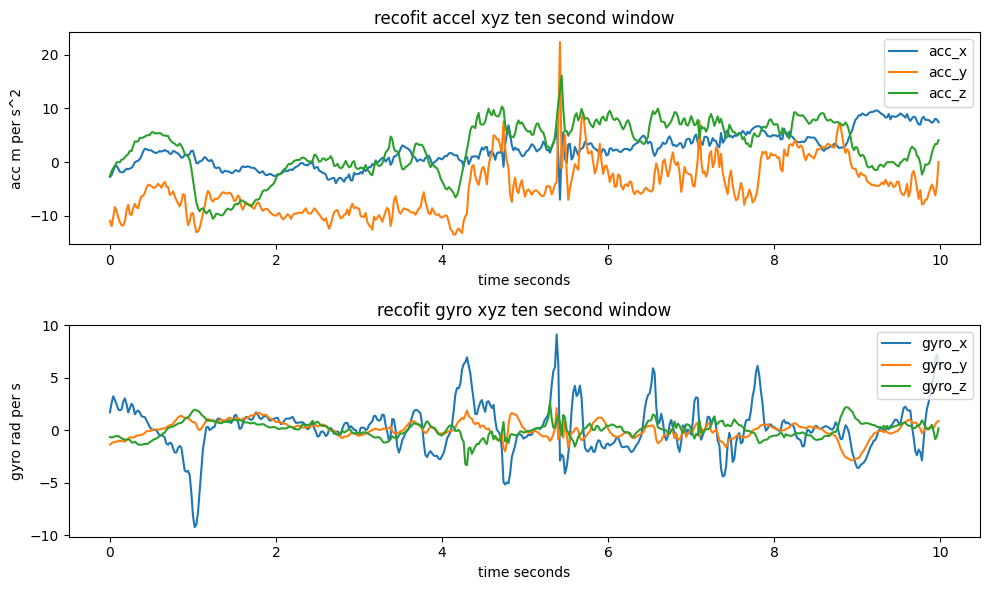

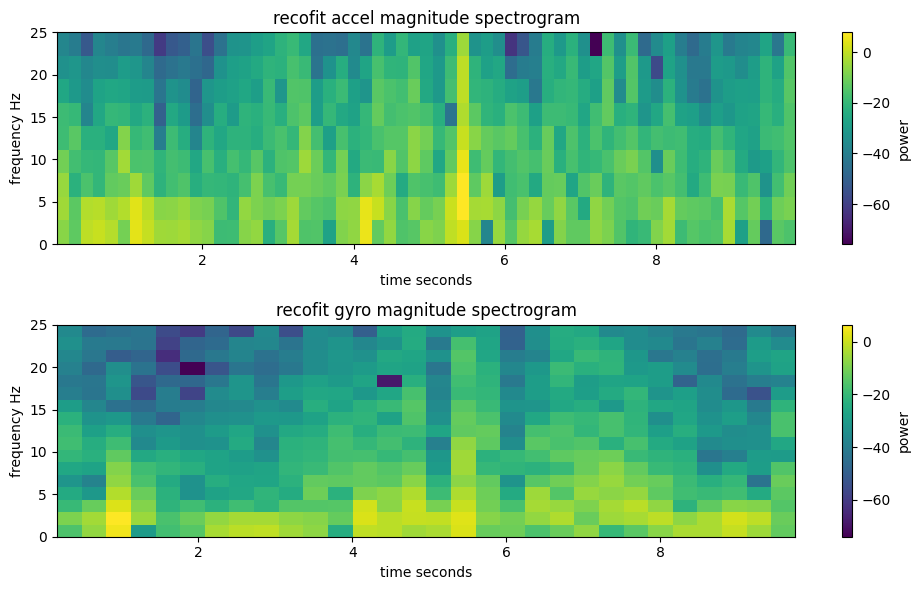

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#df = pd.read_parquet("/home/aidan/IMU_LM_Data/data/merged_dataset/unified_dataset.parquet")

target_dataset = "recofit"
fs = 50.0
window_seconds = 10.0
window_samples = int(window_seconds * fs)

sub = df[df["dataset"] == target_dataset].copy()
sub = sub.sort_values(["subject_id", "session_id", "timestamp_ns"])

# pick a session with enough samples
session_df = None
for (sid, sess), g in sub.groupby(["subject_id", "session_id"]):
    if len(g) >= window_samples:
        session_df = g
        subject_id = sid
        session_id = sess
        break

if session_df is None:
    raise ValueError("no session with enough samples")

segment = session_df.iloc[:window_samples].copy()

# time axis from sample index
n = np.arange(len(segment))
t = n / fs

ax = segment["acc_x"].to_numpy()
ay = segment["acc_y"].to_numpy()
az = segment["acc_z"].to_numpy()

gx = segment["gyro_x"].to_numpy()
gy = segment["gyro_y"].to_numpy()
gz = segment["gyro_z"].to_numpy()

acc_mag = np.sqrt(ax**2 + ay**2 + az**2)
gyro_mag = np.sqrt(gx**2 + gy**2 + gz**2)

# remove mean so gravity and constant bias do not dominate
acc_mag_zm = acc_mag - acc_mag.mean()
gyro_mag_zm = gyro_mag - gyro_mag.mean()

# raw time series
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, ax, label="acc_x")
plt.plot(t, ay, label="acc_y")
plt.plot(t, az, label="acc_z")
plt.xlabel("time seconds")
plt.ylabel("acc m per s^2")
plt.title(f"{target_dataset} accel xyz ten second window")
plt.legend(loc="upper right")

plt.subplot(2, 1, 2)
plt.plot(t, gx, label="gyro_x")
plt.plot(t, gy, label="gyro_y")
plt.plot(t, gz, label="gyro_z")
plt.xlabel("time seconds")
plt.ylabel("gyro rad per s")
plt.title(f"{target_dataset} gyro xyz ten second window")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

# spectrograms
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.specgram(acc_mag_zm, NFFT=16, Fs=fs, noverlap=8)
plt.xlabel("time seconds")
plt.ylabel("frequency Hz")
plt.title(f"{target_dataset} accel magnitude spectrogram")
plt.colorbar(label="power")

plt.subplot(2, 1, 2)
plt.specgram(gyro_mag_zm, NFFT=32, Fs=fs, noverlap=16)
plt.xlabel("time seconds")
plt.ylabel("frequency Hz")
plt.title(f"{target_dataset} gyro magnitude spectrogram")
plt.colorbar(label="power")

plt.tight_layout()
plt.show()


In [7]:

gyro_cols = ["gyro_x", "gyro_y", "gyro_z"]

# per dataset counts and completeness
g = df.groupby("dataset")

out = pd.DataFrame({
    "rows": g.size(),
    "gyro_x_nonnull": g["gyro_x"].count(),
    "gyro_y_nonnull": g["gyro_y"].count(),
    "gyro_z_nonnull": g["gyro_z"].count(),
})

out["gyro_x_pct"] = 100.0 * out["gyro_x_nonnull"] / out["rows"]
out["gyro_y_pct"] = 100.0 * out["gyro_y_nonnull"] / out["rows"]
out["gyro_z_pct"] = 100.0 * out["gyro_z_nonnull"] / out["rows"]

# how many rows have all three gyro axes present
out["gyro_all3_nonnull"] = g.apply(lambda x: x[gyro_cols].notna().all(axis=1).sum())
out["gyro_all3_pct"] = 100.0 * out["gyro_all3_nonnull"] / out["rows"]

print(out.sort_values("gyro_all3_pct", ascending=False))

                  rows  gyro_x_nonnull  gyro_y_nonnull  gyro_z_nonnull  \
dataset                                                                  
pamap2         1271148         1271148         1271148         1271148   
recofit        7751906         7751906         7751906         7751906   
ut_watch       8146709         8146709         8146709         8146709   
samosa         1205141         1205141         1205141         1205141   
opportunity++  1215455               0               0               0   
wear           3466400               0               0               0   

               gyro_x_pct  gyro_y_pct  gyro_z_pct  gyro_all3_nonnull  \
dataset                                                                
pamap2              100.0       100.0       100.0            1271148   
recofit             100.0       100.0       100.0            7751906   
ut_watch            100.0       100.0       100.0            8146709   
samosa              100.0       100.0       100

/tmp/ipykernel_579283/1603468720.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out["gyro_all3_nonnull"] = g.apply(lambda x: x[gyro_cols].notna().all(axis=1).sum())


In [5]:
sub = sub.sort_values(["subject_id", "session_id", "timestamp_ns"])
counts = sub.groupby(["subject_id", "session_id"]).size().sort_values(ascending=False)

print("num sessions", len(counts))
print("top 10 session lengths")
print(counts.head(10))
print("max session length", counts.iloc[0] if len(counts) else None)


num sessions 0
top 10 session lengths
Series([], dtype: int64)
max session length None


In [1]:
import os
import numpy as np
import pandas as pd

# paths
UNIFIED_PARQUET = "/home/aidan/IMU_LM_Data/data/merged_dataset/unified_dataset.parquet"
OUT_PARQUET = "/home/aidan/IMU_LM_Data/data/merged_dataset/unified_dataset_small.parquet"

# sampling
ROWS_PER_DATASET = 5000
SEED = 42

# required columns in your contract
REQ_COLS = [
    "dataset","subject_id","session_id","timestamp_ns",
    "acc_x","acc_y","acc_z","gyro_x","gyro_y","gyro_z",
    "global_activity_id","global_activity_label",
    "dataset_activity_id","dataset_activity_label",
]

# read only needed cols
df = pd.read_parquet(UNIFIED_PARQUET, columns=REQ_COLS)

# keep deterministic
rng = np.random.default_rng(SEED)

# per-dataset row sampling
parts = []
for ds, g in df.groupby("dataset", sort=False):
    n = len(g)
    k = min(int(ROWS_PER_DATASET), n)
    if k == 0:
        continue
    take = rng.choice(n, size=k, replace=False)
    parts.append(g.iloc[take])

small = pd.concat(parts, ignore_index=True)

# optional stable sort to preserve your primary index contract
small = small.sort_values(["dataset","subject_id","session_id","timestamp_ns"]).reset_index(drop=True)

# sanity prints
print("original rows", len(df))
print("small rows", len(small))
print("\nrows per dataset in small")
print(small["dataset"].value_counts())

# write
os.makedirs(os.path.dirname(OUT_PARQUET), exist_ok=True)
small.to_parquet(OUT_PARQUET, index=False)
print("\nwrote", OUT_PARQUET)


original rows 23056759
small rows 30000

rows per dataset in small
dataset
opportunity++    5000
pamap2           5000
recofit          5000
samosa           5000
ut_watch         5000
wear             5000
Name: count, dtype: int64

wrote /home/aidan/IMU_LM_Data/data/merged_dataset/unified_dataset_small.parquet


In [4]:
import pandas as pd
from pathlib import Path

# ---- settings ----
parquet_path = Path("/home/aidan/IMU_LM_Data/data/merged_dataset/unified_dataset.parquet")
expected_hz = 50  # matches config/default.yaml
probe_dataset = "samosa"  # lowercase, so we can drop it if needed
top_k = 10  # how many sessions with the largest gaps to preview
# ------------------

if not parquet_path.exists():
    raise FileNotFoundError(parquet_path)

expected_period_ns = 1e9 / expected_hz
gap_cutoff_ns = 1e9  # ≈1 second; adjust to your preferred threshold

cols = [
    "dataset",
    "subject_id",
    "session_id",
    "timestamp_ns",
]

df = pd.read_parquet(parquet_path, columns=cols).rename(
    columns=lambda c: c.strip().lower()
)
df = df[df["dataset"].str.strip().str.lower() != probe_dataset]

def session_gap_stats(g):
    g = g.sort_values("timestamp_ns")
    diffs = g["timestamp_ns"].diff().dropna()
    return pd.Series(
        {
            "samples": len(g),
            "max_gap_ns": diffs.max() if not diffs.empty else 0,
            "max_gap_seconds": (diffs.max() or 0) / 1e9,
            "num_large_gaps": (diffs > gap_cutoff_ns).sum(),
        }
    )

session_stats = (
    df.groupby(["dataset", "subject_id", "session_id"], sort=False)
      .apply(session_gap_stats)
      .reset_index()
      .sort_values("max_gap_ns", ascending=False)
)

print("Sessions with gaps above the cutoff:")
display(session_stats[session_stats["num_large_gaps"] > 0].head(top_k))

print("\nOverall gap distribution:")
display(
    session_stats["max_gap_seconds"]
    .describe(percentiles=[0.5, 0.9, 0.99])
    .to_frame(name="seconds")
)

# Optional: drill into one specific session
example = session_stats.iloc[0]
mask = (
    (df["dataset"] == example["dataset"])
    & (df["subject_id"] == example["subject_id"])
    & (df["session_id"] == example["session_id"])
)
example_series = df.loc[mask, "timestamp_ns"].sort_values().diff().dropna()
print(
    f"\nLargest gaps for session {tuple(example[['dataset','subject_id','session_id']])}:"
)
print(example_series.sort_values(ascending=False).head(10) / 1e9, "seconds")

Sessions with gaps above the cutoff:


/tmp/ipykernel_616878/532614064.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(session_gap_stats)


,dataset,subject_id,session_id,samples,max_gap_ns,max_gap_seconds,num_large_gaps
25,pamap2,S02,Protocol,113522.0,4.299700e+11,429.97,47.0
27,pamap2,S04,Protocol,104065.0,2.462700e+11,246.27,16.0
24,pamap2,S01,Protocol,112680.0,2.401000e+11,240.10,30.0
34,pamap2,S08,Protocol,118846.0,2.300000e+11,230.00,25.0
31,pamap2,S06,Protocol,117874.0,2.212800e+11,221.28,27.0
29,pamap2,S05,Protocol,126643.0,2.157900e+11,215.79,29.0
32,pamap2,S07,Protocol,106811.0,2.032400e+11,203.24,38.0
26,pamap2,S03,Protocol,82820.0,2.031800e+11,203.18,14.0
35,pamap2,S09,Optional,77406.0,8.827000e+10,88.27,6.0
30,pamap2,S06,Optional,55487.0,7.688000e+10,76.88,2.0



Overall gap distribution:


,seconds
count,2156.000000
mean,1.071053
std,16.008785
min,0.020000
50%,0.020000
90%,0.020000
99%,0.020000
max,429.970000



Largest gaps for session ('pamap2', 'S02', 'Protocol'):
1505649    429.97
1497456    249.58
1513605    191.24
1523376    123.67
1546647    105.27
1501797     99.85
1487157     80.92
1544318     76.49
1449080     62.68
1531786     60.82
Name: timestamp_ns, dtype: float64 seconds


In [5]:
import numpy as np
import pandas as pd
from pathlib import Path

inPath = Path("/home/aidan/IMU_LM_Data/data/merged_dataset/unified_dataset.parquet")
outPath = Path("/home/aidan/IMU_LM_Data/data/merged_dataset/unified_dataset_clean.parquet")

expectedHz = 50
periodNs = int(round(1e9 / expectedHz))

largeGapCutoffSeconds = 1.0
largeGapCutoffNs = int(round(largeGapCutoffSeconds * 1e9))

smallInterpLimitSeconds = 0.2
smallInterpLimitSteps = int(round(smallInterpLimitSeconds * expectedHz))

toleranceNs = periodNs // 2

cols = [
    "dataset",
    "subject_id",
    "session_id",
    "timestamp_ns",
    "acc_x",
    "acc_y",
    "acc_z",
    "gyro_x",
    "gyro_y",
    "gyro_z",
    "global_activity_id",
    "global_activity_label",
    "dataset_activity_id",
    "dataset_activity_label",
]

df = pd.read_parquet(inPath, columns=cols)
df = df.rename(columns=lambda c: c.strip().lower())

df["dataset"] = df["dataset"].astype(str).str.strip().str.lower()

for c in ["subject_id", "session_id", "global_activity_label", "dataset_activity_label"]:
    df[c] = df[c].astype(str)

sensorCols = ["acc_x","acc_y","acc_z","gyro_x","gyro_y","gyro_z"]
labelCols = ["global_activity_id","global_activity_label","dataset_activity_id","dataset_activity_label"]

def cleanGroup(g):
    g = g.sort_values("timestamp_ns").reset_index(drop=True)

    t = g["timestamp_ns"].to_numpy(dtype=np.int64)
    d = np.diff(t)
    splitMask = np.r_[False, d > largeGapCutoffNs]
    segId = splitMask.cumsum()

    pieces = []

    for k in np.unique(segId):
        seg = g.loc[segId == k].copy()
        if len(seg) < 5:
            continue

        t0 = int(seg["timestamp_ns"].iloc[0])
        t1 = int(seg["timestamp_ns"].iloc[-1])

        grid = np.arange(t0, t1 + periodNs, periodNs, dtype=np.int64)
        gridDf = pd.DataFrame({"timestamp_ns": grid})

        merged = pd.merge_asof(
            gridDf,
            seg,
            on="timestamp_ns",
            direction="nearest",
            tolerance=toleranceNs,
        )

        merged[sensorCols] = merged[sensorCols].interpolate(
            method="linear",
            limit=smallInterpLimitSteps,
            limit_direction="both",
        )

        merged[labelCols] = merged[labelCols].ffill()

        merged = merged.dropna(subset=["acc_x","acc_y","acc_z","global_activity_id","dataset_activity_id"])

        if k > 0:
            merged["session_id"] = merged["session_id"].astype(str) + f"_seg{int(k):03d}"

        pieces.append(merged)

    if not pieces:
        return pd.DataFrame(columns=g.columns)

    return pd.concat(pieces, ignore_index=True)

cleaned = (
    df.groupby(["dataset","subject_id","session_id"], sort=False, group_keys=False)
      .apply(cleanGroup)
      .reset_index(drop=True)
)

cleaned["timestamp_ns"] = cleaned["timestamp_ns"].astype("int64")
for c in sensorCols:
    cleaned[c] = cleaned[c].astype("float32")
cleaned["global_activity_id"] = cleaned["global_activity_id"].astype("int16")
cleaned["dataset_activity_id"] = cleaned["dataset_activity_id"].astype("int16")

cleaned = cleaned.sort_values(["dataset","subject_id","session_id","timestamp_ns"]).reset_index(drop=True)

cleaned.to_parquet(outPath, index=False)

print("Wrote", outPath)
print("Rows before", len(df), "rows after", len(cleaned))


/tmp/ipykernel_616878/2789868982.py:98: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(cleanGroup)


Wrote /home/aidan/IMU_LM_Data/data/merged_dataset/unified_dataset_clean.parquet
Rows before 23056759 rows after 23114841


In [9]:
import pandas as pd
from pathlib import Path
from collections import Counter

def validate_sessions(
    parquet_path: str,
    sample_rate_hz: float = 50.0,
    window_seconds: float = 2.56,
    gap_multiplier: float = 1.5,
    dataset_col: str = "dataset",
    subject_col: str = "subject_id",
    session_col: str = "session_id",
    time_col: str = "timestamp_ns",
    required_acc: tuple = ("acc_x", "acc_y", "acc_z"),
    required_gyro: tuple = ("gyro_x", "gyro_y", "gyro_z"),
    label_col: str = "global_activity_id",
):
    path = Path(parquet_path)
    if not path.exists():
        raise FileNotFoundError(path)

    cols_needed = (
        [dataset_col, subject_col, session_col, time_col, label_col]
        + list(required_acc) + list(required_gyro)
    )
    df = pd.read_parquet(path, columns=cols_needed)
    missing = [c for c in cols_needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    df[dataset_col] = df[dataset_col].astype(str).str.strip().str.lower()
    df[subject_col] = df[subject_col].astype(str)
    df[session_col] = df[session_col].astype(str)

    expected_ns = 1e9 / sample_rate_hz
    cutoff_ns = gap_multiplier * expected_ns
    window_size = int(round(sample_rate_hz * window_seconds))

    issues = []
    gap_hist = Counter()
    total_sessions = 0
    viable_sessions = 0

    for (ds, subj, sess), g in df.groupby([dataset_col, subject_col, session_col], sort=False):
        total_sessions += 1
        g = g.sort_values(time_col)
        ts = g[time_col].to_numpy()

        diffs = pd.Series(ts).diff().dropna()
        big_gaps = diffs[diffs > cutoff_ns]

        segments = []
        start = 0
        for idx in big_gaps.index:
            segments.append(g.iloc[start:idx])
            start = idx
        segments.append(g.iloc[start:])

        large_gap_seconds = big_gaps.max() / 1e9 if not big_gaps.empty else 0.0
        windows_in_session = sum(len(seg) >= window_size for seg in segments)

        if windows_in_session == 0:
            issues.append(
                {
                    "dataset": ds,
                    "subject": subj,
                    "session": sess,
                    "total_rows": len(g),
                    "max_gap_s": round(large_gap_seconds, 2),
                    "segments": len(segments),
                    "segments_ge_window": windows_in_session,
                }
            )
        else:
            viable_sessions += 1

        if not big_gaps.empty:
            gap_hist.update({ds: 1})

    summary = {
        "total_sessions": total_sessions,
        "sessions_with_windows": viable_sessions,
        "sessions_without_windows": total_sessions - viable_sessions,
        "percent_viable": (viable_sessions / total_sessions * 100) if total_sessions else 0.0,
        "gap_histogram": dict(gap_hist),
    }

    return summary, pd.DataFrame(issues)

# Example usage
summary, failures = validate_sessions("data/merged_dataset/unified_dataset_clean_v2.parquet", gap_multiplier=10000.0)
print(summary)
display(failures.head())

{'total_sessions': 3853, 'sessions_with_windows': 3853, 'sessions_without_windows': 0, 'percent_viable': 100.0, 'gap_histogram': {}}


""


In [10]:
import numpy as np
import pandas as pd
from pathlib import Path

p = Path("data/merged_dataset/unified_dataset_clean_v2.parquet")

sampleRateHz = 50.0
expectedNs = 1e9 / sampleRateHz
gapMultiplier = 1.5
cutoffNs = gapMultiplier * expectedNs
windowSeconds = 2.56
windowSize = int(round(sampleRateHz * windowSeconds))

cols = [
    "dataset","subject_id","session_id","timestamp_ns",
    "acc_x","acc_y","acc_z","gyro_x","gyro_y","gyro_z",
    "global_activity_id","dataset_activity_id",
    "global_activity_label","dataset_activity_label",
]

df = pd.read_parquet(p, columns=cols)
df = df.rename(columns=lambda c: c.strip().lower())
df["dataset"] = df["dataset"].astype(str).str.strip().str.lower()
df["subject_id"] = df["subject_id"].astype(str)
df["session_id"] = df["session_id"].astype(str)

print("rows", len(df))
print("sessions", df.groupby(["dataset","subject_id","session_id"], sort=False).ngroups)
print(df["dataset"].value_counts().head(20))

sizes = df.groupby(["dataset","subject_id","session_id"], sort=False).size().rename("n").reset_index()
print("min session n", int(sizes["n"].min()))
print("sessions under window", int((sizes["n"] < windowSize).sum()))
print("n quantiles")
print(sizes["n"].quantile([0.01,0.05,0.5,0.95,0.99]).astype(int))

sensorCols = ["acc_x","acc_y","acc_z","gyro_x","gyro_y","gyro_z"]
naRows = df[sensorCols].isna().all(axis=1).mean() * 100
print("rows all sensors NaN percent", round(naRows, 4))

dupKeys = df.duplicated(["dataset","subject_id","session_id","timestamp_ns"]).mean() * 100
print("duplicate primary key percent", round(dupKeys, 6))

def session_dt_stats(g):
    t = g["timestamp_ns"].to_numpy(dtype=np.int64)
    if len(t) < 2:
        return pd.Series({"n": len(t), "median_dt": np.nan, "p99_dt": np.nan, "max_dt": np.nan, "big_gaps": 0})
    d = np.diff(t)
    d = d[d > 0]
    if len(d) == 0:
        return pd.Series({"n": len(t), "median_dt": np.nan, "p99_dt": np.nan, "max_dt": np.nan, "big_gaps": 0})
    return pd.Series({
        "n": len(t),
        "median_dt": float(np.median(d)),
        "p99_dt": float(np.quantile(d, 0.99)),
        "max_dt": float(d.max()),
        "big_gaps": int((d > cutoffNs).sum()),
    })

dt = (
    df.groupby(["dataset","subject_id","session_id"], sort=False)
      .apply(session_dt_stats)
      .reset_index()
)

print("sessions with any big gaps", int((dt["big_gaps"] > 0).sum()))
print("max gap seconds overall", float(dt["max_dt"].max() / 1e9))

rate = 1e9 / dt["median_dt"]
print("median rate hz quantiles")
print(rate.quantile([0.01,0.05,0.5,0.95,0.99]))

print("sessions outside 50 Hz tolerance 0.5 Hz",
      int(((rate < (50 - 0.5)) | (rate > (50 + 0.5))).sum()))

def label_purity_stats(g):
    ids = g["global_activity_id"].to_numpy()
    return pd.Series({
        "n": len(ids),
        "unique_labels": int(pd.Series(ids).nunique()),
        "dominant_frac": float(pd.Series(ids).value_counts(normalize=True).iloc[0]) if len(ids) else np.nan,
    })

pur = (
    df.groupby(["dataset","subject_id","session_id"], sort=False)
      .apply(label_purity_stats)
      .reset_index()
)

print("sessions with more than one global label", int((pur["unique_labels"] > 1).sum()))
print("dominant label frac quantiles")
print(pur["dominant_frac"].quantile([0.01,0.05,0.5,0.95,0.99]))


rows 23047263
sessions 3853
dataset
ut_watch         8146709
recofit          7745226
wear             3466400
pamap2           1268656
opportunity++    1215455
samosa           1204817
Name: count, dtype: int64
min session n 128
sessions under window 0
n quantiles
0.01      169
0.05      276
0.50     1252
0.95    13844
0.99    87752
Name: n, dtype: int64
rows all sensors NaN percent 0.0
duplicate primary key percent 0.0


/tmp/ipykernel_616878/865300255.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(session_dt_stats)


sessions with any big gaps 162
max gap seconds overall 1.0
median rate hz quantiles
0.01    50.0
0.05    50.0
0.50    50.0
0.95    50.0
0.99    50.0
Name: median_dt, dtype: float64
sessions outside 50 Hz tolerance 0.5 Hz 0
sessions with more than one global label 84
dominant label frac quantiles
0.01    0.473566
0.05    1.000000
0.50    1.000000
0.95    1.000000
0.99    1.000000
Name: dominant_frac, dtype: float64


/tmp/ipykernel_616878/865300255.py:86: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(label_purity_stats)


In [8]:
import numpy as np
import pandas as pd
from pathlib import Path

inPath = Path("data/merged_dataset/unified_dataset_clean.parquet")
outPath = Path("data/merged_dataset/unified_dataset_clean_v2.parquet")

sampleRateHz = 50
windowSeconds = 2.56
windowSize = int(round(sampleRateHz * windowSeconds))

cols = [
    "dataset",
    "subject_id",
    "session_id",
    "timestamp_ns",
    "acc_x",
    "acc_y",
    "acc_z",
    "gyro_x",
    "gyro_y",
    "gyro_z",
    "global_activity_id",
    "global_activity_label",
    "dataset_activity_id",
    "dataset_activity_label",
]

df = pd.read_parquet(inPath, columns=cols)
df = df.rename(columns=lambda c: c.strip().lower())

df["dataset"] = df["dataset"].astype(str).str.strip().str.lower()
df["subject_id"] = df["subject_id"].astype(str)
df["session_id"] = df["session_id"].astype(str)

print("rows in", len(df))
print("datasets top")
print(df["dataset"].value_counts().head(20))

badDatasetMask = df["dataset"].isin(["none", "nan", "null", ""])
print("rows with bad dataset value", int(badDatasetMask.sum()))

df = df.loc[~badDatasetMask].copy()

sizes = (
    df.groupby(["dataset", "subject_id", "session_id"], sort=False)
      .size()
      .rename("n")
      .reset_index()
)

short = sizes["n"] < windowSize
print("sessions total", len(sizes))
print("sessions under window", int(short.sum()))

if short.any():
    keepSessions = sizes.loc[~short, ["dataset", "subject_id", "session_id"]]
    keepKey = pd.MultiIndex.from_frame(keepSessions)
    dfKey = pd.MultiIndex.from_frame(df[["dataset", "subject_id", "session_id"]])
    df = df.loc[dfKey.isin(keepKey)].copy()

df = df.sort_values(["dataset", "subject_id", "session_id", "timestamp_ns"]).reset_index(drop=True)

sensorCols = ["acc_x","acc_y","acc_z","gyro_x","gyro_y","gyro_z"]
for c in sensorCols:
    df[c] = df[c].astype("float32")

df["timestamp_ns"] = df["timestamp_ns"].astype("int64")
df["global_activity_id"] = df["global_activity_id"].astype("int16")
df["dataset_activity_id"] = df["dataset_activity_id"].astype("int16")
df["global_activity_label"] = df["global_activity_label"].astype(str)
df["dataset_activity_label"] = df["dataset_activity_label"].astype(str)

print("rows out", len(df))
print("datasets top after")
print(df["dataset"].value_counts().head(20))

sizes2 = (
    df.groupby(["dataset", "subject_id", "session_id"], sort=False)
      .size()
      .rename("n")
      .reset_index()
)
print("sessions out", len(sizes2))
print("min session length", int(sizes2["n"].min()))
print("p01 p05 p50 p95 p99")
print(sizes2["n"].quantile([0.01, 0.05, 0.50, 0.95, 0.99]).astype(int))

df.to_parquet(outPath, index=False)
print("wrote", outPath)


rows in 23114841
datasets top
dataset
ut_watch         8146709
recofit          7751906
wear             3466400
pamap2           1271132
opportunity++    1215455
samosa           1205141
none               58098
Name: count, dtype: int64
rows with bad dataset value 58098
sessions total 4017
sessions under window 164
rows out 23047263
datasets top after
dataset
ut_watch         8146709
recofit          7745226
wear             3466400
pamap2           1268656
opportunity++    1215455
samosa           1204817
Name: count, dtype: int64
sessions out 3853
min session length 128
p01 p05 p50 p95 p99
0.01      169
0.05      276
0.50     1252
0.95    13844
0.99    87752
Name: n, dtype: int64
wrote data/merged_dataset/unified_dataset_clean_v2.parquet


In [14]:
#ell: dataset validation suite (schema + gaps + window counts + ontology checks)
# Requirements: numpy, pandas, pyarrow/fastparquet (for read_parquet)

import json
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

# -------------------------
# USER SETTINGS (edit these)
# -------------------------
DATA_GLOB = "/home/aidan/IMU_LM_Data/data/merged_dataset/unified_dataset_clean_v2.parquet"  # can be a glob like "datadrive/*.parquet"
SCHEMA_JSON_PATH = None  # e.g. "ontology_schema.json" (optional)
OUT_JSON_PATH = "dataset_checks.json"  # where to write the report
MAX_ROWS = None          # e.g. 2_000_000 (optional)
MAX_SESSIONS = None      # e.g. 500 (optional, speeds up session/window scan)
GAP_MULTIPLIER = None    # override (optional). If None, uses config-like default below.
MIN_WINDOWS_PER_CLASS = 50

# Repo-like config (edit if your column names differ)
CFG = {
    "paths": {"data_glob": DATA_GLOB, "out_dir": "."},
    "data": {
        "dataset_column": "dataset",
        "subject_column": "subject_id",
        "session_column": "session_id",
        "time_column": "timestamp_ns",
        "label_id_column": "global_activity_id",
        "label_name_column": "global_activity_label",
        "acc_columns": ["acc_x", "acc_y", "acc_z"],
        "gyro_columns": ["gyro_x", "gyro_y", "gyro_z"],
        "unknown_activity_id": 9000,
        "probe_dataset": "SAMoSA",
        "sample_rate_hz": 50,
        "window_seconds": 2.56,
        "window_hop_ratio": 0.5,
        "gap_cutoff_multiplier": 1.5,  # used if GAP_MULTIPLIER is None
    },
}


# -------------------------
# Helpers (same logic as script)
# -------------------------
def _read_schema(schema_path: Optional[str]) -> Optional[dict]:
    if schema_path is None:
        return None
    p = Path(schema_path)
    if not p.exists():
        raise FileNotFoundError(f"schema file not found: {schema_path}")
    with p.open("r") as f:
        return json.load(f)


def _ensure_columns(df: pd.DataFrame, required: List[str]) -> List[str]:
    return [c for c in required if c not in df.columns]


def _normalize_text_series(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip()


def _session_key_cols(cfg: dict) -> Tuple[str, str, str, str]:
    dcol = cfg["data"]["dataset_column"]
    scol = cfg["data"]["subject_column"]
    secol = cfg["data"]["session_column"]
    tcol = cfg["data"]["time_column"]
    return dcol, scol, secol, tcol


def _expected_ns(sample_rate_hz: float) -> int:
    return int(round(1e9 / float(sample_rate_hz)))


def _gap_cut_ns(cfg: dict, override_gap_mult: Optional[float]) -> int:
    sr = float(cfg["data"]["sample_rate_hz"])
    expected = _expected_ns(sr)
    mult = float(override_gap_mult) if override_gap_mult is not None else float(cfg["data"].get("gap_cutoff_multiplier", 1.5))
    return int(round(mult * expected))


def _analyze_sessions(
    df: pd.DataFrame,
    cfg: dict,
    schema: Optional[dict],
    gap_cut_ns: int,
    max_sessions: Optional[int],
) -> Tuple[Dict[str, object], List[dict]]:
    dcol, scol, secol, tcol = _session_key_cols(cfg)
    ycol = cfg["data"]["label_id_column"]
    yname = cfg["data"]["label_name_column"]

    df = df.copy()
    df[dcol] = _normalize_text_series(df[dcol]).str.lower()
    df[scol] = _normalize_text_series(df[scol])
    df[secol] = _normalize_text_series(df[secol])

    if yname in df.columns:
        df[yname] = _normalize_text_series(df[yname]).str.lower()

    unknown_id = int(schema.get("unknown_activity_id")) if schema and schema.get("unknown_activity_id") is not None else int(cfg["data"].get("unknown_activity_id", 9000))

    label_set = None
    if schema and schema.get("label_set"):
        label_set = {int(x["id"]): str(x.get("name", "")).strip().lower() for x in schema["label_set"]}

    per_session = []
    total_sessions = 0
    non_monotonic_sessions = 0
    rate_stats = []
    gap_sessions = 0
    gap_events = 0
    mixed_label_sessions = 0

    groups = list(df.groupby([dcol, scol, secol], sort=False))
    if max_sessions is not None:
        groups = groups[: int(max_sessions)]

    for (ds, subj, sess), g in groups:
        total_sessions += 1
        ts = g[tcol].to_numpy(dtype=np.int64)
        if ts.size == 0:
            continue

        ts_sorted = np.sort(ts)
        mono = bool(np.all(ts_sorted[1:] >= ts_sorted[:-1]))
        if not mono:
            non_monotonic_sessions += 1

        diffs = np.diff(ts_sorted)
        if diffs.size > 0:
            med = float(np.median(diffs))
            rate_stats.append(med)
            gaps = diffs > gap_cut_ns
            n_gaps = int(np.sum(gaps))
        else:
            med = float("nan")
            n_gaps = 0

        if n_gaps > 0:
            gap_sessions += 1
            gap_events += n_gaps

        y = g[ycol].to_numpy()
        unique_y = set(int(v) for v in np.unique(y) if pd.notna(v))
        mixed = len(unique_y) > 1
        if mixed:
            mixed_label_sessions += 1

        session_len = int(len(g))
        unknown_count = int(np.sum(y == unknown_id))

        bad_label_ids = []
        if label_set is not None:
            for v in unique_y:
                if v not in label_set:
                    bad_label_ids.append(int(v))

        name_mismatch = False
        if label_set is not None and yname in g.columns:
            expected_names = {int(k): v for k, v in label_set.items()}
            for lid in unique_y:
                exp = expected_names.get(int(lid), None)
                if exp is None:
                    continue
                observed = set(str(x).strip().lower() for x in g[g[ycol] == lid][yname].dropna().unique().tolist())
                if len(observed) > 0 and (exp not in observed):
                    name_mismatch = True
                    break

        per_session.append(
            {
                "dataset": str(ds),
                "subject_id": str(subj),
                "session_id": str(sess),
                "rows": session_len,
                "unique_global_activity_ids": sorted([int(x) for x in unique_y]),
                "unknown_activity_rows": unknown_count,
                "non_monotonic_ts": not mono,
                "median_dt_ns": med,
                "gap_count": n_gaps,
                "label_ids_not_in_label_set": bad_label_ids,
                "label_name_mismatch": bool(name_mismatch),
                "mixed_labels_in_session": bool(mixed),
            }
        )

    med_dt_ns = float(np.median(np.array(rate_stats))) if len(rate_stats) else float("nan")
    return (
        {
            "sessions_analyzed": int(total_sessions),
            "sessions_non_monotonic": int(non_monotonic_sessions),
            "sessions_with_gaps": int(gap_sessions),
            "gap_events": int(gap_events),
            "sessions_with_mixed_labels": int(mixed_label_sessions),
            "median_dt_ns_over_sessions": med_dt_ns,
        },
        per_session,
    )


def _window_counts(
    df: pd.DataFrame,
    cfg: dict,
    schema: Optional[dict],
    max_sessions: Optional[int],
) -> Dict[str, object]:
    dcol, scol, secol, tcol = _session_key_cols(cfg)
    ycol = cfg["data"]["label_id_column"]

    sample_rate = float(cfg["data"]["sample_rate_hz"])
    win_sec = float(cfg["data"]["window_seconds"])
    hop_ratio = float(cfg["data"]["window_hop_ratio"])

    w = int(round(sample_rate * win_sec))
    hop = max(1, int(round(w * hop_ratio)))

    unknown_id = int(schema.get("unknown_activity_id")) if schema and schema.get("unknown_activity_id") is not None else int(cfg["data"].get("unknown_activity_id", 9000))

    df = df.copy()
    df[dcol] = _normalize_text_series(df[dcol]).str.lower()
    df[scol] = _normalize_text_series(df[scol])
    df[secol] = _normalize_text_series(df[secol])

    groups = list(df.groupby([dcol, scol, secol], sort=False))
    if max_sessions is not None:
        groups = groups[: int(max_sessions)]

    per_label = {}
    mixed_windows = 0
    total_windows = 0

    for _, g in groups:
        g = g.sort_values(tcol)
        y = g[ycol].to_numpy(dtype=np.int64)
        n = len(y)
        i = 0
        while i + w <= n:
            y_win = y[i : i + w]
            total_windows += 1
            if not np.all(y_win == y_win[0]):
                mixed_windows += 1
                i += hop
                continue
            lab = int(y_win[0])
            per_label[lab] = per_label.get(lab, 0) + 1
            i += hop

    labels_sorted = sorted(per_label.items(), key=lambda kv: (-kv[1], kv[0]))
    unknown_windows = int(per_label.get(unknown_id, 0))

    return {
        "window_size_samples": int(w),
        "hop_samples": int(hop),
        "total_windows": int(total_windows),
        "mixed_label_windows": int(mixed_windows),
        "unknown_label_windows": int(unknown_windows),
        "windows_per_global_activity_id": {str(int(k)): int(v) for k, v in labels_sorted},
    }


def _basic_column_stats(df: pd.DataFrame, cfg: dict) -> Dict[str, object]:
    dcol, scol, secol, tcol = _session_key_cols(cfg)
    ycol = cfg["data"]["label_id_column"]
    yname = cfg["data"]["label_name_column"]

    out = {
        "rows": int(len(df)),
        "unique_datasets": int(df[dcol].nunique()) if dcol in df.columns else 0,
        "unique_subjects": int(df[scol].nunique()) if scol in df.columns else 0,
        "unique_sessions": int(df[[dcol, scol, secol]].drop_duplicates().shape[0]) if all(c in df.columns for c in [dcol, scol, secol]) else 0,
    }

    if ycol in df.columns:
        out["unique_global_activity_ids"] = int(df[ycol].nunique())
    if yname in df.columns:
        out["unique_global_activity_labels"] = int(df[yname].astype(str).str.strip().str.lower().nunique())

    if tcol in df.columns and len(df) > 0:
        out["timestamp_min_ns"] = int(pd.to_numeric(df[tcol], errors="coerce").min())
        out["timestamp_max_ns"] = int(pd.to_numeric(df[tcol], errors="coerce").max())

    return out


def _save_json(obj: dict, path: str) -> None:
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    with p.open("w") as f:
        json.dump(obj, f, indent=2, sort_keys=True)


# -------------------------
# Run checks
# -------------------------
schema = _read_schema(SCHEMA_JSON_PATH)

import glob

pattern = CFG["paths"]["data_glob"]
paths = sorted(Path(p) for p in glob.glob(pattern))
if not paths:
    raise FileNotFoundError(f"No parquet files matched {CFG['paths']['data_glob']}")

frames = []
for p in paths:
    dfi = pd.read_parquet(p)
    if MAX_ROWS is not None and len(dfi) > int(MAX_ROWS):
        dfi = dfi.iloc[: int(MAX_ROWS)]
    frames.append(dfi)

df = pd.concat(frames, axis=0, ignore_index=True) if len(frames) > 1 else frames[0]

required_cols = [
    CFG["data"]["dataset_column"],
    CFG["data"]["subject_column"],
    CFG["data"]["session_column"],
    CFG["data"]["time_column"],
    *CFG["data"]["acc_columns"],
    CFG["data"]["label_id_column"],
    CFG["data"]["label_name_column"],
]
required_cols.extend(CFG["data"].get("gyro_columns", []))

missing = _ensure_columns(df, required_cols)

null_report = {}
for c in required_cols:
    if c in df.columns:
        null_report[c] = int(df[c].isna().sum())

gap_cut_ns = _gap_cut_ns(CFG, GAP_MULTIPLIER)

session_summary, per_session = _analyze_sessions(
    df,
    CFG,
    schema,
    gap_cut_ns=gap_cut_ns,
    max_sessions=MAX_SESSIONS,
)

window_summary = _window_counts(df, CFG, schema, max_sessions=MAX_SESSIONS)

low_classes = []
for k, v in window_summary["windows_per_global_activity_id"].items():
    if int(v) < int(MIN_WINDOWS_PER_CLASS):
        low_classes.append({"global_activity_id": int(k), "windows": int(v)})

probe_ds = str(CFG["data"]["probe_dataset"]).strip().lower()
dcol = CFG["data"]["dataset_column"]
probe_rows = int((_normalize_text_series(df[dcol]).str.lower() == probe_ds).sum()) if dcol in df.columns else 0

report = {
    "data_glob": CFG["paths"]["data_glob"],
    "files": [str(p) for p in paths],
    "missing_required_columns": missing,
    "null_counts": null_report,
    "basic": _basic_column_stats(df, CFG),
    "probe_dataset": probe_ds,
    "probe_rows": probe_rows,
    "gap_cut_ns": int(gap_cut_ns),
    "sessions": session_summary,
    "windowing": window_summary,
    "classes_below_min_windows": low_classes,
    # If you want detailed per-session rows, uncomment the next line (can be large):
    # "per_session": per_session,
}

_save_json(report, OUT_JSON_PATH)

print("=== Dataset Check Summary ===")
print("files", len(paths), "rows", report["basic"]["rows"])
if missing:
    print("missing required columns:")
    for c in missing:
        print(" -", c)
else:
    print("required columns: OK")

print("sessions analyzed", report["sessions"]["sessions_analyzed"], "sessions with gaps", report["sessions"]["sessions_with_gaps"])
print("mixed-label windows", report["windowing"]["mixed_label_windows"], "/", report["windowing"]["total_windows"])
print("classes below", int(MIN_WINDOWS_PER_CLASS), "windows:", len(low_classes))
print("wrote", OUT_JSON_PATH)

=== Dataset Check Summary ===
files 1 rows 23047263
required columns: OK
sessions analyzed 3853 sessions with gaps 162
mixed-label windows 13453 / 354381
classes below 50 windows: 0
wrote dataset_checks.json
